In [1]:
import sys
print(sys.executable)

c:\Amdari_Dev\Project - Trendify - Sentiment Analysis\Trendify_Sentiment\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/reviews_cleaned.csv")

df.head()

,review_id,product_category,timestamp,country,rating,review,sentiment,review_clean
0,1,Books,2023-01-01,GB,3,"Solid build, attractive design, works as adver...",positive,"solid build, attractive design, works as adver..."
1,2,Toys,2023-01-01,DE,5,Ich liebe dieses Produkt! ⭐⭐⭐,positive,ich liebe dieses produkt! star star star
2,3,Beauty,2023-01-01,AU,3,Three stars — meets THE minimum expectations.,neutral,three stars - meets the minimum expectations.
3,4,Toys,2023-01-01,US,5,"Solid build, attractive design, works as adver...",positive,"solid build, attractive design, works as adver..."
4,5,Electronics,2023-01-01,CA,2,Broken on arrival. Return process was a NIGHTM...,negative,broken on arrival. return process was a nightm...


In [4]:
# Check the shape of the dataset
df.shape

(120000, 8)

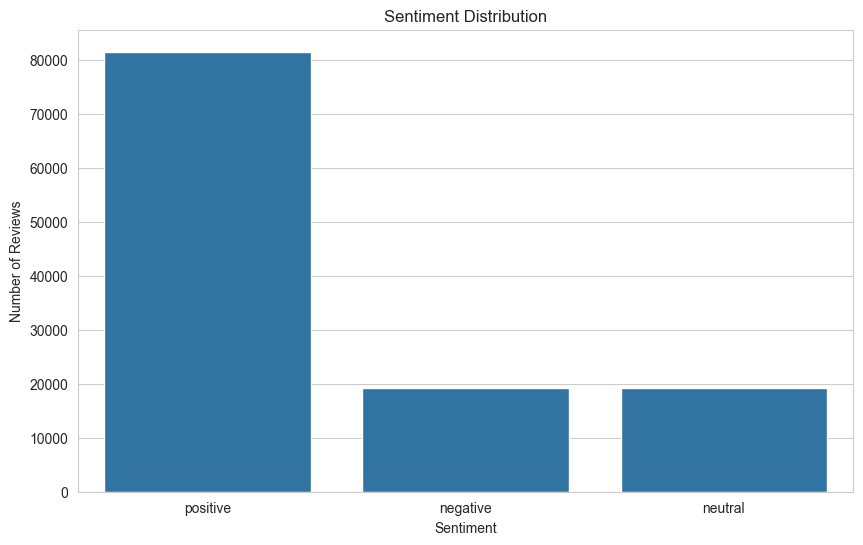

In [5]:
# Check Sentiment Distribution
sentiment_counts = df["sentiment"].value_counts()

sns.countplot(data=df, x="sentiment", order=sentiment_counts.index)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Positive reviews dominate the dataset, representing approximately 80% of all feedback, while negative & neutral reviews account for 20%.

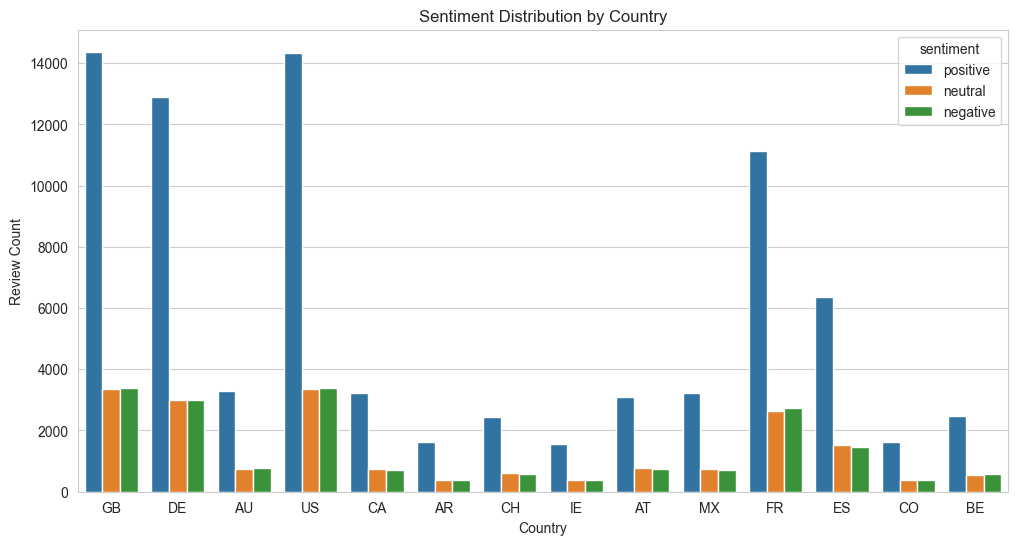

In [6]:
# Check Sentiment distribution by Country 
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="country", hue="sentiment")

plt.title("Sentiment Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Review Count")

plt.show()

The UK, the US, Denmark & France are the countries with the most postive, negative and neutral sentiments in that order while the least were Argentina, IE & Span.

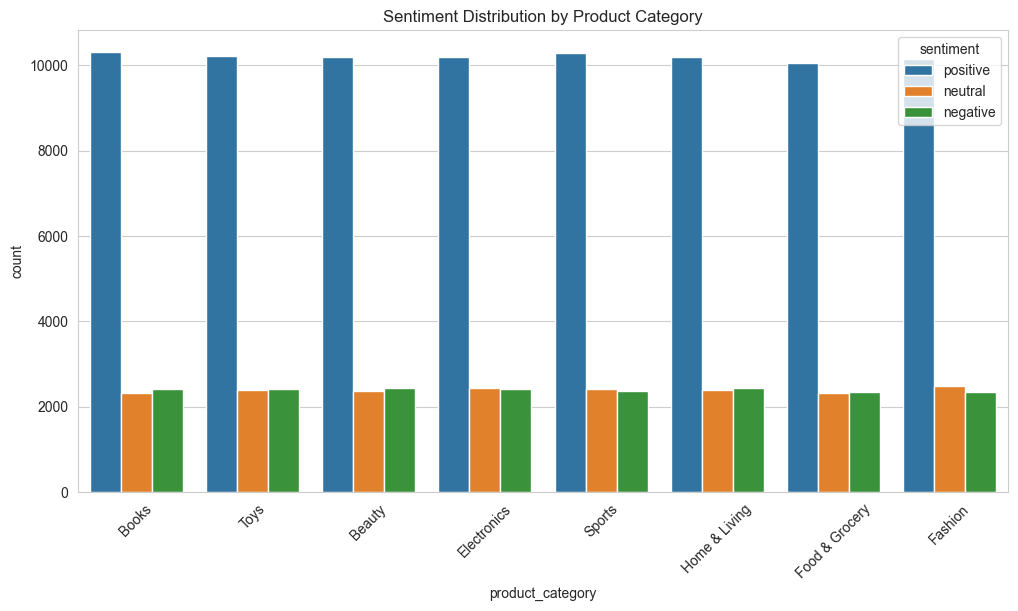

In [7]:
# Check sentiment distribution by Product Category
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="product_category", hue="sentiment")

plt.xticks(rotation=45)

plt.title("Sentiment Distribution by Product Category")

plt.show()

Positive sentiments were more in all product category.

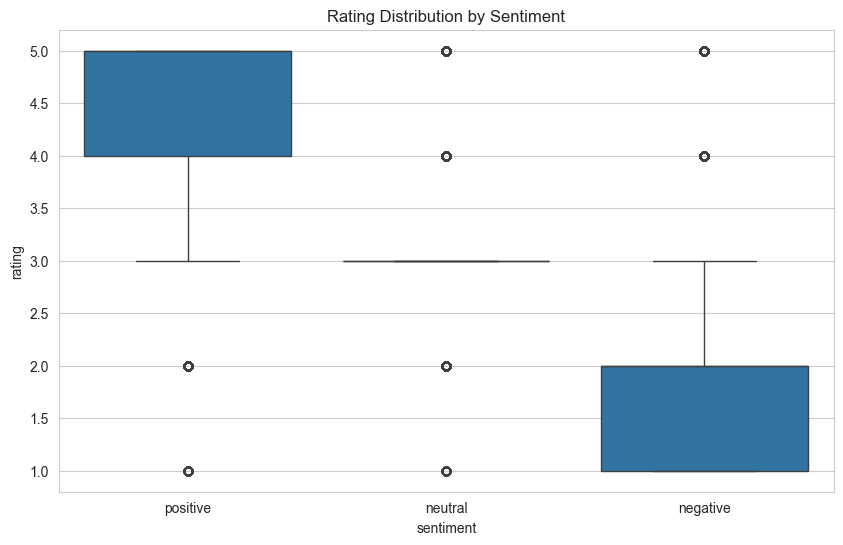

In [8]:
# Checking sentiment distribution by Rating
sns.boxplot(data=df, x="sentiment", y="rating")

plt.title("Rating Distribution by Sentiment")

plt.show()

In [10]:
# Checking most commmon words 
text = " ".join(df["review_clean"])

words = re.findall(r'\b[a-z]{3,}\b', text)

word_counts = Counter(words)

common_words = word_counts.most_common(20)

common_words

[('and', 12671),
 ('product', 11974),
 ('produit', 11712),
 ('quality', 10840),
 ('the', 10560),
 ('produkt', 9323),
 ('this', 9008),
 ('was', 8911),
 ('exactly', 8328),
 ('very', 7791),
 ('sehr', 7729),
 ('for', 7214),
 ('excellent', 6892),
 ('muy', 6362),
 ('great', 6092),
 ('best', 5552),
 ('highly', 5529),
 ('recommend', 5529),
 ('money', 5478),
 ('delivery', 5453)]

'and' occured most while the word 'delivery' occured least. 

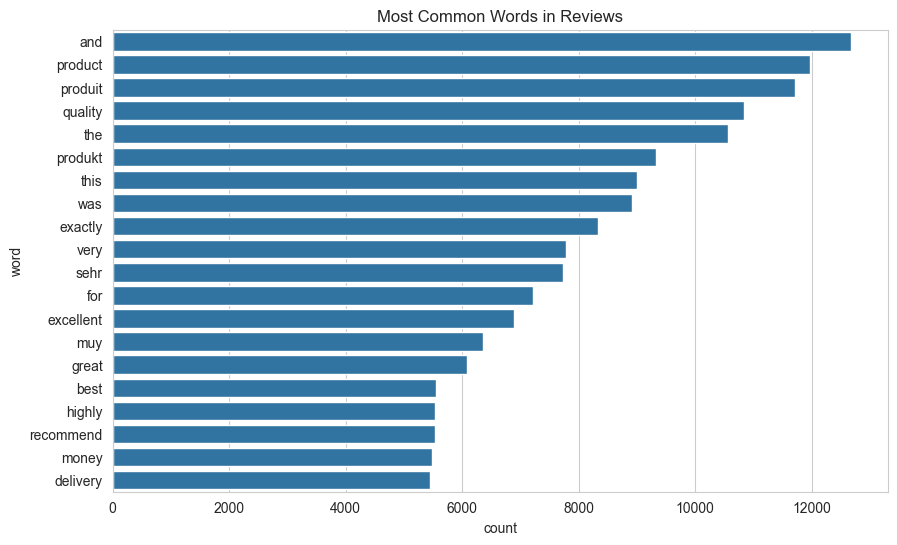

In [12]:
# Ploting the most common words
words_df = pd.DataFrame(common_words, columns=["word","count"])

sns.barplot(data=words_df, x="count", y="word")

plt.title("Most Common Words in Reviews")

plt.show()

In [16]:
# Keywords by Sentiment : Positive words
positive_text = " ".join(df[df["sentiment"]=="positive"]["review_clean"])

WordCloud(width=800,height=400,background_color="white").generate(positive_text)

Text(0.5, 1.0, 'Positive Review Word Cloud')

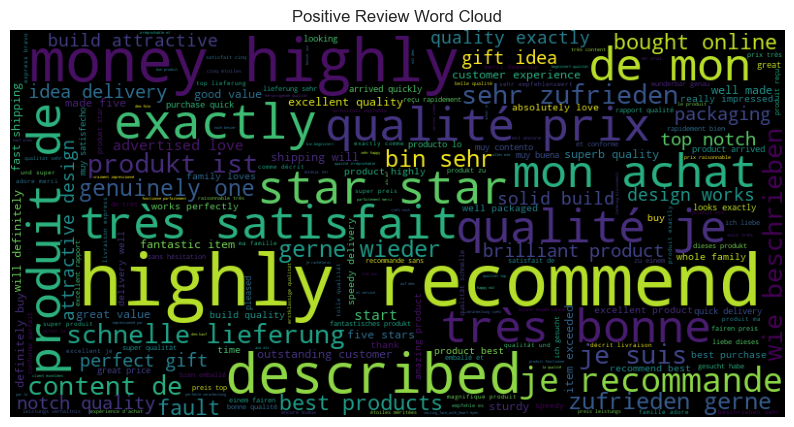

In [17]:
plt.imshow(WordCloud(width=800,height=400).generate(positive_text))
plt.axis("off")
plt.title("Positive Review Word Cloud")

In [18]:
# Keywords by Sentiment: Negative words
negative_text = " ".join(df[df["sentiment"]=="negative"]["review_clean"])

Text(0.5, 1.0, 'Negative Review Word Cloud')

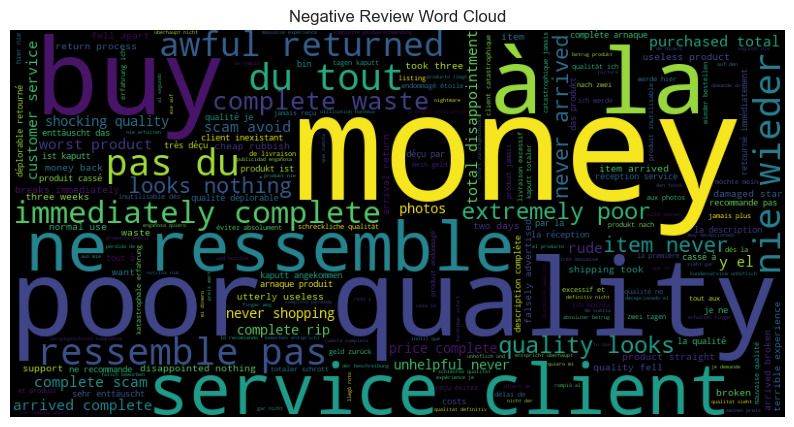

In [19]:
plt.imshow(WordCloud(width=800,height=400).generate(negative_text))
plt.axis("off")
plt.title("Negative Review Word Cloud")

In [20]:
# Save my visualizations for Report
plt.savefig("../reports/figures/sentiment_distribution.png")

<Figure size 1000x600 with 0 Axes>